In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

X = torch.tensor([
    [50, 1, 10],
    [60, 2, 8],
    [80, 2, 5],
    [100, 3, 4],
    [120, 3, 2],
    [150, 4, 1]
], dtype=torch.float32)

y = torch.tensor(
    [100, 130, 180, 220, 270, 330],
    dtype=torch.float32
)

In [5]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1=nn.Linear(3,16)
        self.relu=nn.ReLU()
        self.linear2=nn.Linear(16,1)
    def forward(self,X):
        X=self.linear1(X)
        X=self.relu(X)
        X=self.linear2(X)
        return X


In [6]:
model=MLP()
print(model)


MLP(
  (linear1): Linear(in_features=3, out_features=16, bias=True)
  (relu): ReLU()
  (linear2): Linear(in_features=16, out_features=1, bias=True)
)


最终损失: 6251.900390625
预测结果: tensor([199.8239, 199.8239, 199.8239, 199.8239, 199.8239, 199.8239])


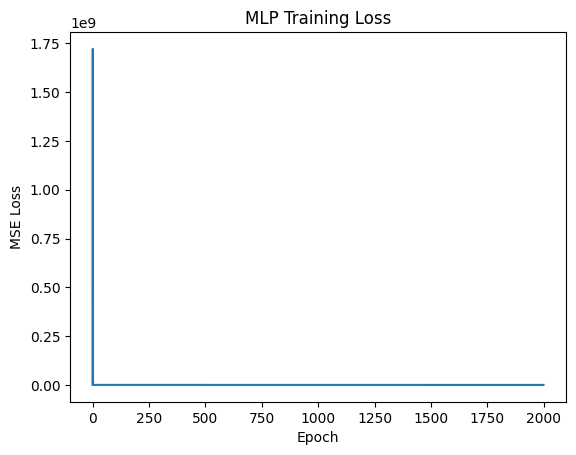

In [7]:
model=MLP()
loss_fn=nn.MSELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.001)
epochs=2000
loss_history=[]
for epoch in range(epochs):
    # 前向传播
    y_pred=model(X)
    # 计算损失
    loss=loss_fn(y_pred.squeeze(),y)
    
    # 反向传播
    loss.backward()
    # 更新参数
    optimizer.step()
    # 清零梯度
    optimizer.zero_grad()
    loss_history.append(loss.item())
print("最终损失:", loss_history[-1])
print("预测结果:", model(X).squeeze().detach())
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("MLP Training Loss")
plt.show()

In [8]:
### 小实验之用MLP拟合线性函数
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

X = torch.linspace(-3, 3, 200).reshape(-1, 1)
y = torch.sin(X)
# 它可以按照顺序进行前向传播
model = nn.Sequential(
    nn.Linear(1, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

loss_history = []

for epoch in range(2000):
    y_pred = model(X)

    loss = loss_fn(y_pred, y)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    loss_history.append(loss.item())

print("最终损失:", loss_history[-1])

最终损失: 5.696511834685225e-06


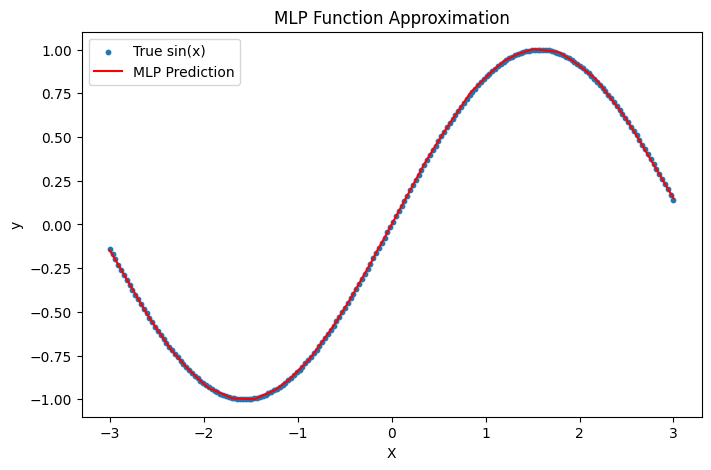

In [ ]:
model.eval()

with torch.no_grad():
    prediction = model(X)
# 在这里我们只是想看看模型预测得怎么样而已

plt.figure(figsize=(8, 5))  # 这里是建立一张画布

plt.scatter(X.numpy(), y.numpy(), label="True sin(x)", s=10)
plt.plot(X.numpy(), prediction.numpy(), color="red", label="MLP Prediction")

plt.legend()
plt.xlabel("X")
plt.ylabel("y")
plt.title("MLP Function Approximation")
plt.show()